In [3]:
# pip install xarray

Note: you may need to restart the kernel to use updated packages.


In [4]:
#pip install cartopy

  Using cached cartopy-0.25.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (6.1 kB)
  Using cached pyshp-3.0.3-py3-none-any.whl.metadata (65 kB)
Using cached cartopy-0.25.0-cp311-cp311-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (11.8 MB)
Using cached pyshp-3.0.3-py3-none-any.whl (58 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
#pip install netcdf4

  Using cached netcdf4-1.7.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (2.1 kB)
  Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (8.7 kB)
Using cached netcdf4-1.7.4-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (10.4 MB)
Using cached cftime-1.6.5-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (1.7 MB)
Note: you may need to restart the kernel to use updated packages.


# <font color="red"> **3.2 Anomalías**

En Ciencias de la Tierra, **comprender el comportamiento de una variable no depende únicamente de su valor observado, sino de cómo este se compara con sus condiciones habituales**. En este sentido, entender el cambio resulta más relevante que el valor en sí, y **las anomalías constituyen una herramienta fundamental para cuantificar dichas variaciones**. Además, las anomalías permite **identificar patrones, entender la variabilidad y detectar cambios relevantes en el tiempo y el espacio**.

---------------------------
## <font color="darkblue">¿Qué es una anomalía?

Una anomalía es la diferencia entre un valor observado y un valor de referencia, generalmente un promedio o una condición considerada “normal”.

**Fórmula básica:**

$$
 \text{Anomalía} = \text{valor observado} - \text{valor de referencia}
$$


### <font color="brown"> **Tipos de anomalías**</font>

* Anomalía absoluta
* Anomalía porcentual
* Anomalía estandarizada

#### ¡Vamos a ver cada una!

---------------------------

### <font color="olivedrab">**Anomalía absoluta**

Este es el tipo de anomalía más simple. **Representa la diferencia directa entre un valor observado respecto al promedio**. Anomalías mayores a cero, valores observados por encima de lo normal; menores a cero, valores por debajo de lo normal; e iguales a cero, valores iguales al promedio.

$$
A = x - \mu
$$

donde $𝑥$ es el valor observado y $\mu$ el valor promedio.

`Nota:La anomalía absoluta mantiene las mismas unidades que la variable.`

**¿Cómo la interpretamos?**
- A > 0 → Valores observados por encima del promedio
- A < 0 → Valores por debajo del promedio
- A = 0 → Valores iguales al promedio


Calculemos nuestra primer anomalía :)

In [6]:
#Pero antes, vamos a cargar las librerías necesarias para este notebook
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib as mpl

#### <font color="orange"> **Ejemplo 1: Anomalía absoluta**

In [9]:
#Vamos a cargar los datos que ocuparemos
#Ocuparemos datos sobre las características de los jugadores en el videojuego FIFA19
ruta='/home/jovyan/Clase/TemasSelectos/data/fifa_data.csv'
fifa=pd.read_csv(ruta)

In [10]:
#Vamos a ver nuestros datos
fifa

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,18202,238813,J. Lundstram,19,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47,65,Crewe Alexandra,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,18203,243165,N. Christoffersson,19,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47,63,Trelleborgs FF,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,18204,241638,B. Worman,16,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47,67,Cambridge United,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,18205,246268,D. Walker-Rice,17,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47,66,Tranmere Rovers,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


In [11]:
#Vamos a seleccionar las columnas de Overall y Club
fifa_slice=fifa[["Club","Overall"]]
fifa_slice.head()

,Club,Overall
0,FC Barcelona,94
1,Juventus,94
2,Paris Saint-Germain,92
3,Manchester United,91
4,Manchester City,91


Vamos a suponer que queremos *conocer la diferencia entre el rendimiento promedio de cada club respecto al promedio de todos los equipos*. 

In [12]:
#Paso 1: Calcular promedio
overall_mean=np.mean(fifa_slice["Overall"]).round(2)
overall_mean

np.float64(66.24)

In [13]:
#Paso 2: Calcular la anomalía

#Podemos calcular la anomalía de algún equipo de su preferencia, por ejemplo el del Chelsea 
valor_obs=(fifa_slice[fifa_slice["Club"]=="Chelsea"])["Overall"].mean().round(2)
valor_obs

#Aplicamos la fórmula de anomalía absoluta
anom_chelsea=(valor_obs-overall_mean).round(2)
anom_chelsea

np.float64(10.55)

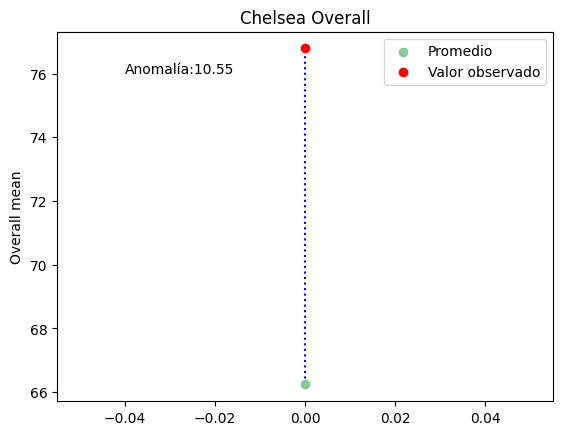

In [14]:
#Paso 3: ¿Cómo lo visualizamos?

#Dado que sólo calculamos una anomalía, la visualización es un poco "simple". 
#Para no graficar solo el punto de la anomalía, hacemos una gráfica donde podamos ver la diferencia entre
#el valor observado y el promedio

#Graficamos el valor de x y el valor del promedio global
plt.scatter(x = 0, y = overall_mean, color = '#88c999',label="Promedio") #x=0 nos ayudará a centrar el plot
plt.scatter(x = 0, y = valor_obs, color = 'red',label="Valor observado")

#Graficamos una línea que nos permita conectar el valor promedio con el observado
#zorder nos ayuda a determinar el orden en el que se plotean los elementos, 0 es hasta el fondo
plt.plot([0, 0], [overall_mean, valor_obs], color = 'blue', linestyle = ':', zorder = 0) 

#Podemos poner el valor de la anomalía en la gráfica
plt.text(-0.04,76,"Anomalía:"+str(anom_chelsea))

plt.ylabel("Overall mean")
plt.legend()
plt.title("Chelsea Overall")
plt.show()  #¿Qué pueden interpretar de la gráfica?

Como pueden observar, la gráfica en sí no dice mucho. Esto se debe a que **los datos están tomados en un momento particular entonces no podemos ver si hay alguna evolución en el tiempo**. No obstante sí que podemos hacer otras cosas.


#### <font color="orange"> **Ejemplo 2:** 

Supongamos que queremos comparar no el promedio, sino los valores particulares de cada jugador comparado con el promedio global.

In [15]:
# Vamos a seguir trabajando con el club de Chelsea

#Paso 1: Hacemos el recorte de los jugadores que pertenezcan al Chelsea
chelsea_players = fifa_slice[fifa_slice['Club'] == 'Chelsea']

#Paso 2: Ahora obtenemos la anomalía pero de cada jugador
anom_team_chelsea = chelsea_players['Overall'] - overall_mean

print(anom_team_chelsea.head())

5      24.76
14     22.76
69     19.76
121    17.76
140    17.76
Name: Overall, dtype: float64


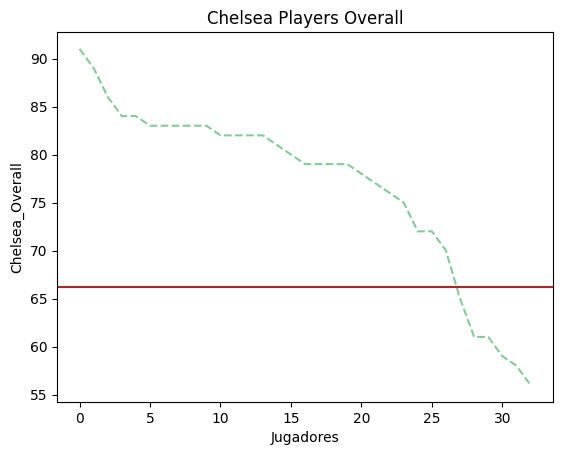

In [16]:
#Paso 3: ¿Cómo graficamos?

#Primero vamos a graficar el comportamiento del overall de cada jugador del Chelsea

#Creamos un arreglo para los valores en el eje X, que representan a los jugadores
x = np.arange(len(anom_team_chelsea))

#Graficamos el valor de x(observado) y el valor del promedio grobal
plt.plot(x, chelsea_players['Overall'], linestyle="--",color = '#88c999')

#Dado que el promedio grobal es un valor único, podemos trazar una línea horizontal en dicho valor
plt.axhline(y = overall_mean, color='brown', linestyle='-')

plt.xlabel("Jugadores")
plt.ylabel("Chelsea_Overall")
plt.title("Chelsea Players Overall")

plt.show() #¿Con esta gráfica qué pueden intuir del comportamiento de las anomalías?

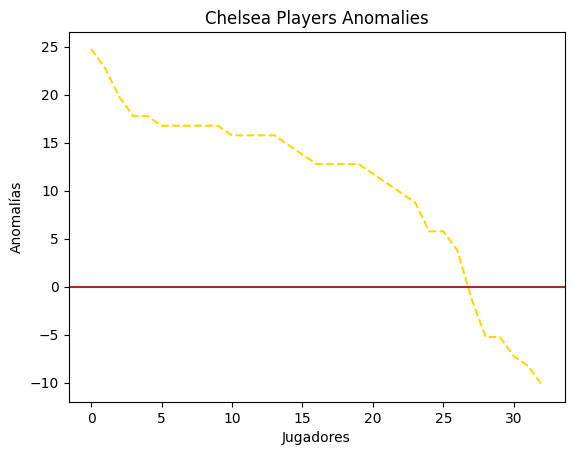

In [17]:
#Ahora vamos a graficar el comportamiento de las anomalías

plt.plot(x, anom_team_chelsea,color="gold", linestyle="--")

#Vamos a centrar nuestra línea en horizontal en 0, que es donde el valor es igual al promedio
plt.axhline(y = 0, color='brown', linestyle='-')

plt.ylabel("Anomalías")
plt.xlabel("Jugadores")
plt.title("Chelsea Players Anomalies")
plt.show()

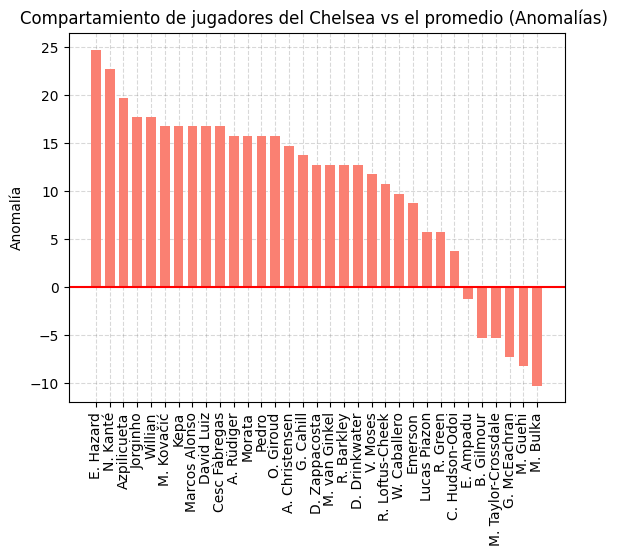

In [18]:
#Ahora una forma más bonita de plotear anomalías 

#Usando bar plots

#Vamos a obtener los nombres de los jugadores del chelsea
fifa_chelsea_names=fifa[fifa["Club"]=="Chelsea"]["Name"]

plt.bar(fifa_chelsea_names, anom_team_chelsea, color = "salmon", width = 0.7,zorder=2)

plt.title('Compartamiento de jugadores del Chelsea vs el promedio (Anomalías) ')
plt.ylabel('Anomalía')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.show()

#Recuerden que lo importante es la interpretación 
#¿Qué significa cada barra? y ¿Qué podemos saber de cada jugador a partir de ella?

La grafica anterior no es mal gráfico pero ya es momento que hagan visualizaciones cada vez más interesantes.


#### <font color="orange"> **Ejemplo 3:**

Supongamos que son entrenadores y quieren resaltar a los jugadores que estén  10 puntos por arriba de la media así como los que están por debajo de la media.

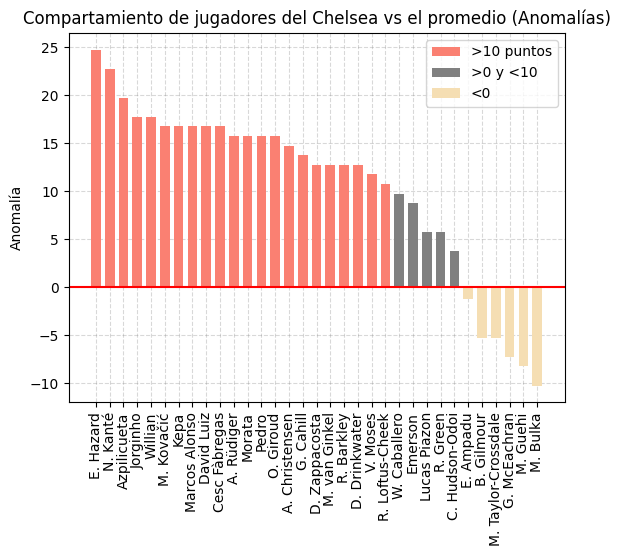

In [19]:
#Vamos a retomar los nombres de los jugadores y los valores de las anomalías
anom_team_chelsea
fifa_chelsea_names

#Vamos a localizar los jugadores que cumplan con las siguientes condiciones:

#Jugadores con 10 puntos por arriba de la media
a=anom_team_chelsea.loc[anom_team_chelsea>10]

#Jugadores por debajo de la media
b=anom_team_chelsea.loc[anom_team_chelsea<0]

#Jugadores que no cumplen con ninguna condición anterior
c=anom_team_chelsea.loc[(anom_team_chelsea>0)&(anom_team_chelsea<10)]

#Graficamos, OJO: CUIDADO CON EL ORDEN EN EL QUE GRAFICAN
plt.bar(fifa_chelsea_names[a.index], a, color ="salmon", width = 0.7,label=">10 puntos",zorder=2)
plt.bar(fifa_chelsea_names[c.index], c, color ="grey", width = 0.7,label=">0 y <10",zorder=2)
plt.bar(fifa_chelsea_names[b.index], b, color ="wheat", width = 0.7,label="<0",zorder=2)
        
plt.title('Compartamiento de jugadores del Chelsea vs el promedio (Anomalías)')
plt.ylabel('Anomalía')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.legend()
plt.show()


--------------
### <font color="olivedrab"> **Anomalía porcentual**

La `anomalía porcentual` expresa la diferencia entre un valor observado y un valor de referencia en términos relativos, es decir, como un **porcentaje del promedio**. Este tipo de anomalía permite comparar la magnitud del cambio de forma proporcional, independientemente de las unidades de la variable.


$$
A_{\%} = \frac{x - \mu}{\mu} \times 100
$$

donde $𝑥$ es el valor observado y $\mu$ el valor promedio.

**¿Cómo la interpretamos?**

* $A_{\%}$ > 0 → valor por encima de lo normal
* $A_{\%}$ < 0 → valor por debajo de lo normal
* $A_{\%}$ = 0 → valor igual al promedio

*Básicamente una anomalía porcentual en vez de considerar el 0 como línea base, considera que el 100$%$ es el 0, entonces las anomalías se van a moverse alrededor de ese valor.*

#### <font color="orange" > **Ejemplo 1:**

In [20]:
#Si observan la fórmula de la anomalía porcentual, esta se obtiene al dividir la anomalía 
#absoluta con el promedio y multiplicar el resultado x100

#Vamos a retomar las anomalías del comportamiento de los jugadores del chelsea y el promedio 
mean=overall_mean
anom_team_chelsea

# Hacemos la operación
anom_perc=lambda anom_abs: (anom_abs/mean )*100
chelsea_perc=anom_team_chelsea.apply(anom_perc)
chelsea_perc.head()

5      37.379227
14     34.359903
69     29.830918
121    26.811594
140    26.811594
Name: Overall, dtype: float64

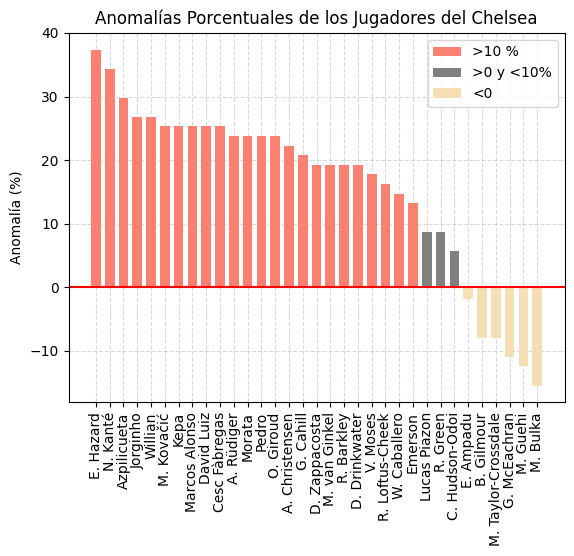

In [21]:
#Vamos a graficar, considerando las mismas condiciones del ejercicio 3 de anomalías absolutas
#pero ahora en porcentajes

#Vamos a localizar los jugadores que cumplan con las siguientes condiciones:

#Jugadores con 10% por arriba del total de datos
a=chelsea_perc.loc[chelsea_perc>10]

#Jugadores por debajo del total de datos, recuerden que el 0 representa mi 100%
b=chelsea_perc.loc[chelsea_perc<0]

#Jugadores que no cumplen con ninguna condición anterior
c=chelsea_perc.loc[(chelsea_perc>0)&(chelsea_perc<10)]

#Graficamos, OJO: CUIDADO CON EL ORDEN EN EL QUE GRAFICAN
plt.bar(fifa_chelsea_names[a.index], a, color ="salmon", width = 0.7,label=">10 %",zorder=2)
plt.bar(fifa_chelsea_names[c.index], c, color ="grey", width = 0.7,label=">0 y <10%",zorder=2)
plt.bar(fifa_chelsea_names[b.index], b, color ="wheat", width = 0.7,label="<0",zorder=2)
        
plt.title('Anomalías Porcentuales de los Jugadores del Chelsea')
plt.ylabel('Anomalía (%)')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.legend()
plt.show()

#¿Cómo interpretamos este tipo de anomalía?

------

### <font color="olivedrab"> **Anomalía estandarizada ($Z-score$)**

La `anomalía estandarizada` es una medida que *expresa la diferencia entre un valor observado y su promedio en términos de desviaciones estándar*. **No tiene unidades, lo que permite comparar variables con distintas escalas o magnitudes**.

$$
Z = \frac{x - \mu}{\sigma}
$$

donde $𝑥$ es el valor observado, $\mu$ el valor promedio y $\sigma$ la desviación estándar.

**¿Cómo la interpretamos?**

* $Z$ > 0 → valor por encima de lo normal
* $Z$ < 0 → valor por debajo de lo normal
* $Z$ = 0 → valor igual al promedio

* *Magnitud del cambio*
     * $∣𝑍|$ < 1 → variación normal
     * $∣𝑍|$ ≈ 2 → evento poco común
     * $∣𝑍|$ ≥ 2 → evento extremo


<font color="brown">**La anomalía estandarizada permite evaluar qué tan inusual es un valor dentro de la variabilidad natural de los datos.**

#### <font color="orange"> **Ejemplo 1:**

In [22]:
#Vamos a obtener la anomalía estandarizada del comportamiento de los jugadores del Chelsea

#Retomamos los valores de la anomalía de los jugadores del Chelsea 
anom_team_chelsea


#Vamos a calcular la desviación estándar, ¿A qué debo de sacarle la desviación?
desv_chelsea=np.std(fifa_slice["Overall"]).round(2)

#Z-score
z_score_chelsea=(anom_team_chelsea/desv_chelsea).round(2)

z_score_chelsea.head()

5      3.58
14     3.29
69     2.86
121    2.57
140    2.57
Name: Overall, dtype: float64

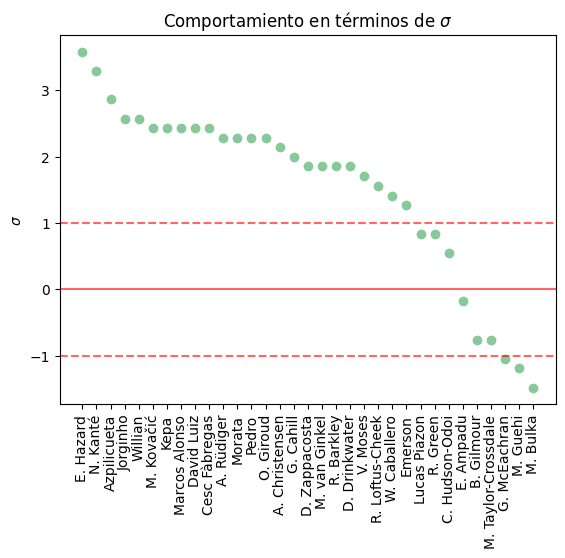

In [23]:
#Vamos a graficar

#Nombres de los jugadores
x = fifa_chelsea_names

#Graficando las anomalías estandarizadas
plt.scatter(x, z_score_chelsea, color = '#88c999')

#Para ver qué jugadores están por encima o por debajo de 1 desviación estándar
plt.axhline(y = 0, color = 'r', linestyle='-', alpha = 0.6)
plt.axhline(y = 1, color = 'r', linestyle='--', alpha = 0.6)
plt.axhline(y = -1, color = 'r', linestyle='--', alpha = 0.6)
plt.ylabel("$\sigma$")
plt.xticks(rotation=90)
plt.title("Comportamiento en términos de $\sigma$")
plt.show()

#¿Qué podemos interpretar de la gráfica?

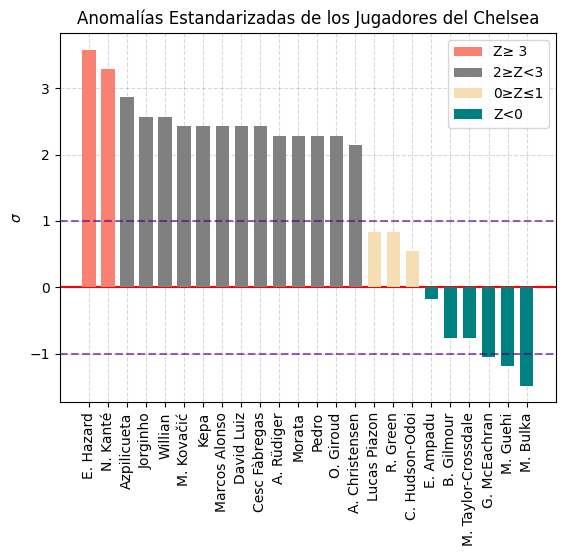

In [26]:
#Vamos a hacer un gráfico diferente para ver a los jugadores que su desempeño tienen una 
#desviación estándar de 0 a 1, de 2 a 3, mayorese iguales a 3, y los que estén por debajo de 0 desvest

#Vamos a localizar los jugadores que cumplan con las siguientes condiciones:

#Jugadores con 0 y 1 desvets por arriba de la media
a=z_score_chelsea.loc[(z_score_chelsea>=0) & (z_score_chelsea<=1)]

#Jugadores con 2 desvest por arriba de la media
b=z_score_chelsea.loc[(z_score_chelsea>=2) & (z_score_chelsea<3)]

#Jugadores con más de 3 desvest por encima de la media
c=z_score_chelsea.loc[(z_score_chelsea>=3)]

#Jugadores con debajo de 0 desvest de la media
d=z_score_chelsea.loc[(z_score_chelsea<0)]


#Graficamos
plt.bar(fifa_chelsea_names[c.index], c, color ="salmon", width = 0.7,label="Z≥ 3",zorder=3)
plt.bar(fifa_chelsea_names[b.index], b, color ="grey", width = 0.7,label="2≥Z<3",zorder=3)
plt.bar(fifa_chelsea_names[a.index], a, color ="wheat", width = 0.7,label="0≥Z≤1",zorder=3)
plt.bar(fifa_chelsea_names[d.index], d, color ="teal", width = 0.7,label="Z<0",zorder=3)
        
plt.title('Anomalías Estandarizadas de los Jugadores del Chelsea')
plt.ylabel('$\sigma$')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')

#1 desvest por encima y debajo de la media
plt.axhline(y = 1, color = 'indigo', linestyle='--', alpha = 0.6,zorder=3)
plt.axhline(y = -1, color = 'indigo', linestyle='--', alpha = 0.6,zorder=3)


plt.legend()
plt.show()

#### **Resumen de los tres tipos de anomalías**

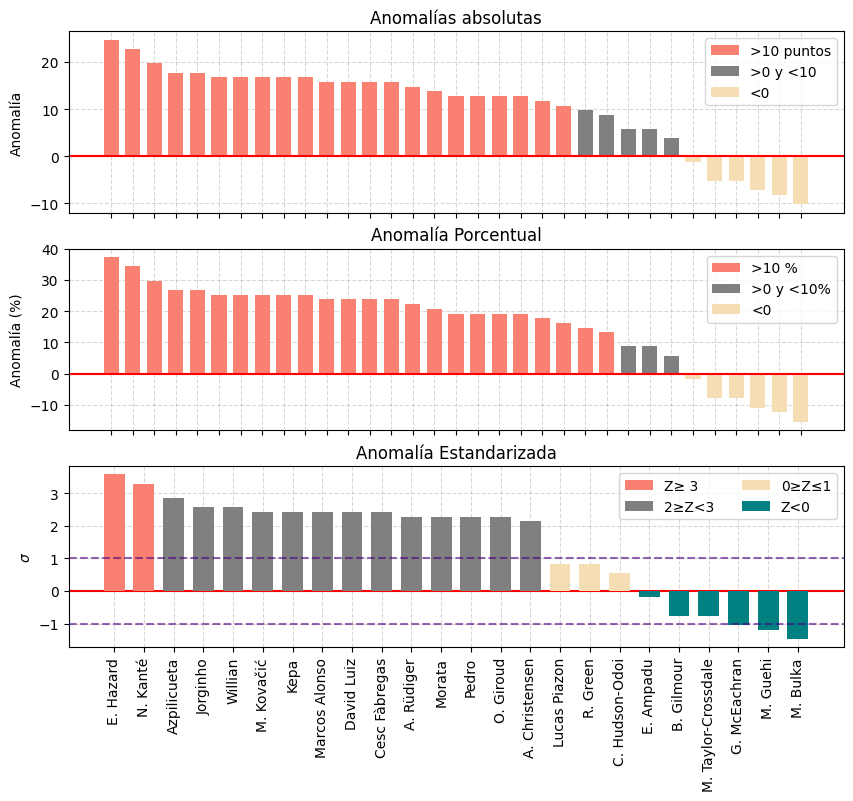

<Figure size 640x480 with 0 Axes>

In [27]:
#Para ello, compararemos las tres gráficas de las anomalías de los jugadores del chelsea
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
#Vamos a retomar los nombres de los jugadores y los valores de las anomalías
anom_team_chelsea
fifa_chelsea_names

#Vamos a localizar los jugadores que cumplan con las siguientes condiciones:

#Jugadores con 10 puntos por arriba de la media
a=anom_team_chelsea.loc[anom_team_chelsea>10]

#Jugadores por debajo de la media
b=anom_team_chelsea.loc[anom_team_chelsea<0]

#Jugadores que no cumplen con ninguna condición anterior
c=anom_team_chelsea.loc[(anom_team_chelsea>0)&(anom_team_chelsea<10)]

#Graficamos, OJO: CUIDADO CON EL ORDEN EN EL QUE GRAFICAN
plt.bar(fifa_chelsea_names[a.index], a, color ="salmon", width = 0.7,label=">10 puntos",zorder=2)
plt.bar(fifa_chelsea_names[c.index], c, color ="grey", width = 0.7,label=">0 y <10",zorder=2)
plt.bar(fifa_chelsea_names[b.index], b, color ="wheat", width = 0.7,label="<0",zorder=2)
        
plt.title('Anomalías absolutas')
plt.ylabel('Anomalía')
plt.xticks(rotation = 90,color="white")
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.legend()

plt.subplot(3,1,2)

#Jugadores con 10% por arriba de la media
a=chelsea_perc.loc[chelsea_perc>10]

#Jugadores por debajo de la media
b=chelsea_perc.loc[chelsea_perc<0]

#Jugadores que no cumplen con ninguna condición anterior
c=chelsea_perc.loc[(chelsea_perc>0)&(chelsea_perc<10)]

#Graficamos, OJO: CUIDADO CON EL ORDEN EN EL QUE GRAFICAN
plt.bar(fifa_chelsea_names[a.index], a, color ="salmon", width = 0.7,label=">10 %",zorder=2)
plt.bar(fifa_chelsea_names[c.index], c, color ="grey", width = 0.7,label=">0 y <10%",zorder=2)
plt.bar(fifa_chelsea_names[b.index], b, color ="wheat", width = 0.7,label="<0",zorder=2)
        
plt.title('Anomalía Porcentual')
plt.ylabel('Anomalía (%)')
plt.xticks(rotation = 90,color="white")
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.legend()


plt.subplot(3,1,3)
#Jugadores con 0 y 1 desvets por arriba de la media
a=z_score_chelsea.loc[(z_score_chelsea>=0) & (z_score_chelsea<=1)]

#Jugadores entre 2 y 3 desvest por arriba de la media
b=z_score_chelsea.loc[(z_score_chelsea>=2) & (z_score_chelsea<3)]

#Jugadores con más e igual a 3 desvest por encima de la media
c=z_score_chelsea.loc[(z_score_chelsea>=3)]

#Jugadores con debajo de 0 desvest de la media
d=z_score_chelsea.loc[(z_score_chelsea<0)]


#Graficamos
plt.bar(fifa_chelsea_names[c.index], c, color ="salmon", width = 0.7,label="Z≥ 3",zorder=3)
plt.bar(fifa_chelsea_names[b.index], b, color ="grey", width = 0.7,label="2≥Z<3",zorder=3)
plt.bar(fifa_chelsea_names[a.index], a, color ="wheat", width = 0.7,label="0≥Z≤1",zorder=3)
plt.bar(fifa_chelsea_names[d.index], d, color ="teal", width = 0.7,label="Z<0",zorder=3)
        
plt.title('Anomalía Estandarizada')
plt.ylabel('$\sigma$')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')

#1 desvest por encima y debajo de la media
plt.axhline(y = 1, color = 'indigo', linestyle='--', alpha = 0.6,zorder=3)
plt.axhline(y = -1, color = 'indigo', linestyle='--', alpha = 0.6,zorder=3)

plt.legend(ncols=2)
plt.show()
plt.tight_layout(w_pad=1.5)

 <font color="brown"> **Interpretación**

En el primer panel (anomalías absolutas), se muestra la diferencia directa respecto al promedio. Esta representación es útil para ver cuánto aporta o se desvía cada jugador en términos reales, pero no considera la variabilidad de los datos.

En el segundo panel (anomalía porcentual), los mismos datos se expresan en términos relativos. Esto permite comparar mejor la magnitud del cambio entre jugadores, destacando quiénes tienen incrementos o déficits importantes en proporción al promedio. Aunque el patrón general es similar al de la anomalía absoluta, aquí se enfatiza la intensidad relativa del rendimiento, lo que puede cambiar ligeramente la percepción de qué jugadores destacan más.

En el tercer panel (anomalía estandarizada), los valores se expresan en unidades de desviación estándar. Esto introduce la variabilidad de los datos y permite identificar qué tan inusual es el rendimiento de cada jugador. Los jugadores con valores mayores a 3 desviaciones estándar (en salmón) pueden considerarse rendimientos excepcionalmente altos, mientras que los valores negativos indican desempeños por debajo de lo esperado. Esta métrica es especialmente útil para detectar eventos extremos o atípicos, más allá de la magnitud absoluta o relativa.

La elección del tipo de anomalía influye en la interpretación: mientras unas destacan la magnitud del cambio, otras resaltan su importancia relativa o su rareza dentro de la distribución.

------
**En resumen:**

Las anomalías pueden expresarse de distintas formas según el tipo de información que se desea analizar. La `anomalía absoluta` representa la diferencia directa entre un valor observado y su promedio, y se utiliza cuando interesa conocer el cambio en términos reales y en las mismas unidades de la variable. La `anomalía porcentual` expresa esa diferencia de manera relativa, como un porcentaje, lo que permite comparar cambios entre variables o regiones con distintas magnitudes. Por su parte, la `anomalía estandarizada` mide la desviación en función de la variabilidad de los datos, utilizando la desviación estándar, lo que permite evaluar qué tan inusual es un valor dentro de su distribución.

En conjunto, la principal diferencia entre ellas radica en su forma de interpretación: *la anomalía absoluta indica cuánto cambia una variable, la porcentual cuánto cambia en términos relativos y la estandarizada qué tan significativo o atípico es ese cambio dentro de la variabilidad natural de los datos.*

---------

### <font color="purple"> Ejercicio 1

A partir de los datos de `Datos_Poblacion.csv`, realiza lo siguiente:

* Selecciona las columnas de `Country` e `Infant mortality`
* Calcula el Z-score de la mortalidad infantil para cada país
* Selecciona 10 países. Grafica y describe tus resultados.



In [28]:
#Cargando los datos
pob=pd.read_csv("/home/jovyan/Clase/TemasSelectos/data/Datos_Poblacion.csv")

In [30]:
#Seleccionando las columnas de Country e Infant mortality
inf_mort = pob[['Country','Infant mortality']]
inf_mort.head()

,Country,Infant mortality
0,Algeria,31.00
1,Angola,191.19
2,Benin,85.00
3,Botswana,54.58
4,Burkina Faso,97.57


In [36]:
#Vamos a calcular el Z-Score

#Calculamos la desviación estándar
pob_std=np.std(inf_mort["Infant mortality"])

#Calculamos el promedio
pob_mean=np.mean(inf_mort["Infant mortality"])

#Calculamos el Z-score
pob_zscore=(inf_mort["Infant mortality"]-pob_mean)/pob_std

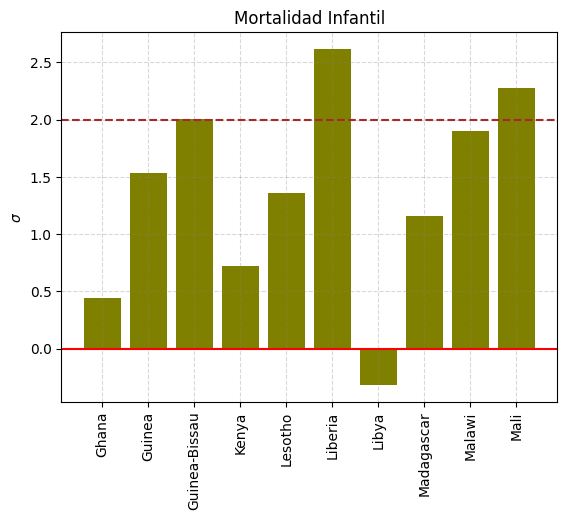

In [47]:

plt.bar(inf_mort["Country"][20:30],pob_zscore[20:30],color="olive")
plt.xticks(rotation=90)
plt.title('Mortalidad Infantil')
plt.ylabel('$\sigma$')
plt.xticks(rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.axhline(y = 0, color='red', linestyle='-')
plt.axhline(y = 2, color='brown', linestyle='--')
plt.show()

<font color="brown"> **Interpertación**

En la gráfica observamos el Z-score sobre la mortalidad infantil de 10 países de África. De acuerdo a los resultados, los países de Liberia y Mali presentan una mortalidad infantil extrema, es decir, una cantidad excepcional de niños pierden la vida en estos países en comparación al promedio mundial. Por otro lado, países como Guinea, Guinea-Bissau, Lesotho, Madagascar y Malawi presentan una mortalidad infantil menos extrema pero relevantes. Mientras que Ghana y Kenya presentan mortalidad infanil similar a la del promedio mundial. Algo a destacar es que Libya tiene una mortalidad infantil cercana al promedio pero negativa, es decir, en Libya mueren menos niños en comparación al promedio.

----------------

## <font color="brown">¿Y cómo son las anomalías en Ciencias de la Tierra?

Hasta ahora utilizamos datos de rendimiento de jugadores para entender cómo funcionan las anomalías. Sin embargo, este mismo enfoque es ampliamente utilizado en las Ciencias de la Tierra pero con un enfoque de temporal y espacial. Esto permite identificar patrones, detectar eventos extremos y comprender mejor la variabilidad de los sistemas naturales.

**¿Cómo funcionan?**

En lugar de analizar datos en un momento específico, en CT se calculan las anomalías tomando un periodo de referencia, que suele ser un promedio histórico. Esto tranforma los datos en una medida de cambio, no solo de estado.

$$
\text{Anomalía}=\text{valor observado} - \text{promedio histórico}
$$

**Usos**

* Detectar variabilidad natural
* Identificar eventos inusuales (estandarizadas)
* Comparar regiones con características diferentes (estandarizadas o porcentuales)
* Analizar tendencias

**Anomalías en Ciencias de la Tierra**

| Área | Variable | Ejemplo de anomalía | Uso principal |
|------|---------|--------------------|---------------|
| Atmósfera | Temperatura | +2°C respecto al promedio | Detectar olas de calor y cambio climático |
| Atmósfera | Precipitación | −20% de lluvia | Identificar sequías o déficit hídrico |
| Oceanografía | Temperatura superficial del mar | +1.5°C | Analizar calentamiento oceánico y variabilidad climática |
| Hidrología | Caudal de ríos | −30% del promedio | Evaluar sequías o disponibilidad de agua |
| Geofísica | Gravedad | Anomalía positiva | Detectar estructuras del subsuelo |
| Criósfera | Extensión de hielo | −15% | Monitorear deshielo |
| Energía | Generación eólica | +25% | Analizar variabilidad energética |
| Ciencias espaciales | Radiación solar | Incremento anómalo | Detectar tormentas solares |
| Ciencias espaciales | Campo magnético | Desviaciones | Identificar tormentas geomagnéticas |
| Observación satelital | NDVI (vegetación) | −0.2 | Detectar estrés vegetal |


¡Vamos a calcular anomalías de precipitación!

#### <font color="orange">**Ejemplo 1: Anomalías absolutas**

In [49]:
#Cargamos nuestros datos
ruta='/home/jovyan/Clase/TemasSelectos/data/Mexico_ppt.nc'
rain=xr.open_dataset(ruta)

#Vamos a ver lo que contiene nuestros datos , frecuencia de los datos?
rain

<xarray.Dataset> Size: 257MB
Dimensions:    (time: 396, latitude: 231, longitude: 351)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1990-01-01 1990-02-01 ... 2022-12-01
  * latitude   (latitude) float32 924B 33.0 32.9 32.8 32.7 ... 10.2 10.1 10.0
  * longitude  (longitude) float32 1kB -118.0 -117.9 -117.8 ... -83.1 -83.0
Data variables:
    tp         (time, latitude, longitude) float64 257MB ...
Attributes:
    Conventions:  CF-1.6
    history:      2024-04-24 04:54:45 GMT by grib_to_netcdf-2.24.0: /opt/ecmw...

In [50]:
#Vamos a seleccionar la variable tp
rain_Mexico=rain["tp"]
rain_Mexico

#Dados que nuestros datos estan en m por mes, los vamos a convertir en mm por mes
rain_Mexico_mm=rain_Mexico*(30.436875*1000)

In [51]:
#Ya que tenemos nuestros datos vamos a calcular la anomalía absoluta

#Paso 1: Elegimos nuestro periodo base (1991-2001)
periodo_base=rain_Mexico_mm.where((rain_Mexico_mm.time.dt.year>1990) & (rain_Mexico_mm.time.dt.year<2002),drop=True)
periodo_base

#Paso 2: Promediamos el periodo base
promedio_ref=periodo_base.mean("time")
promedio_ref

#Paso 3: Seleccionamos un año que queramos analizar, en este caso vamos a elegir el 2020
anio_ref= rain_Mexico_mm.where((rain_Mexico_mm.time.dt.year==2020),drop=True)
anio_ref
anio_ref_mean=anio_ref.mean("time")

#Paso 4: Realizamos la operación para obtener la anomalía absoluta
anom_abs_rain=anio_ref_mean-promedio_ref

#Paso 5: Graficamos

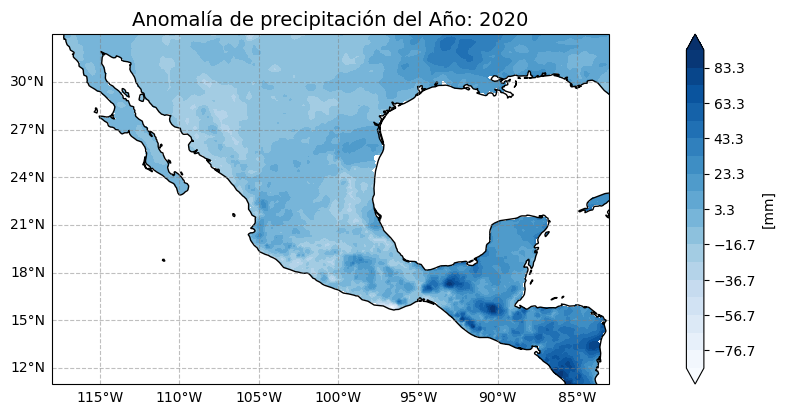

In [52]:
#Vamos a graficar
fig = plt.figure(figsize=(10,10))

ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-118,-83, 11, 33], crs=ccrs.PlateCarree())
ax.coastlines()
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False

#Seleccionamos los valores de latitud y longitud
lon=anom_abs_rain.longitude
lat=anom_abs_rain.latitude

cs = ax.contourf(lon, lat, anom_abs_rain, levels = np.arange(anom_abs_rain.min(), anom_abs_rain.max(), 10),extend="both", cmap = 'Blues', transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[mm]')

plt.title('Anomalía de precipitación del Año: 2020', fontsize = 14)
plt.show()

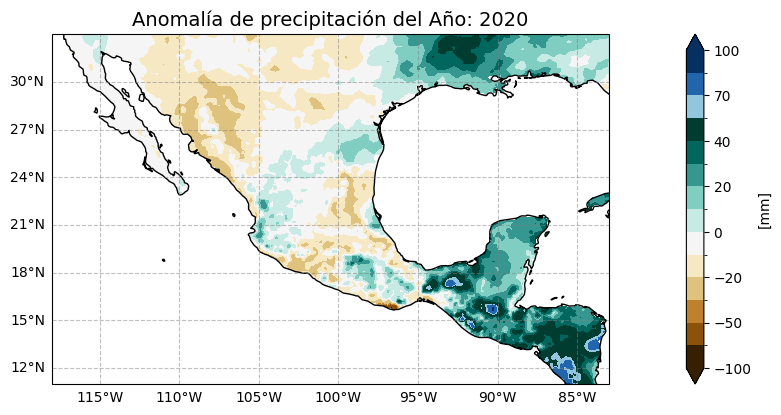

In [53]:
#Pueden definir sus propias barras de colores

# Limites
bounds = [-100,-80,-50,-40,-20,-10,0,10,20,30,40,60,70,90,100]
colors = ['#372001','#8C510B','#BF812E','#DFC27E','#F6E8C3','#F5F5F5','#C7EAE4','#80CEC1','#369790','#01665E','#003C30','#92C6DE','#2165AC','#063062']

# Rampa
my_map = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bounds, my_map.N)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-118,-83, 11, 33], crs=ccrs.PlateCarree())
ax.coastlines()
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False #Para solo poner una vez las latitudes y longitudes

cs = ax.contourf(lon, lat, anom_abs_rain, levels = bounds, cmap = my_map, norm = norm, extend="both", transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[mm]')
plt.title('Anomalía de precipitación del Año: 2020', fontsize = 14)

plt.show()

#¿Cómo interpretamos el mapa?

#### <font color="orange"> **Ejemplo 2: Anomalías porcentuales**


In [54]:
#La anomalía porcentual se calculaba dividiendo la anomalía absoluta entre el promedio y multiplicando dicho resultado x100

#Calculamos anomalía porcentual
anom_perc_rain=(anom_abs_rain/promedio_ref)*100

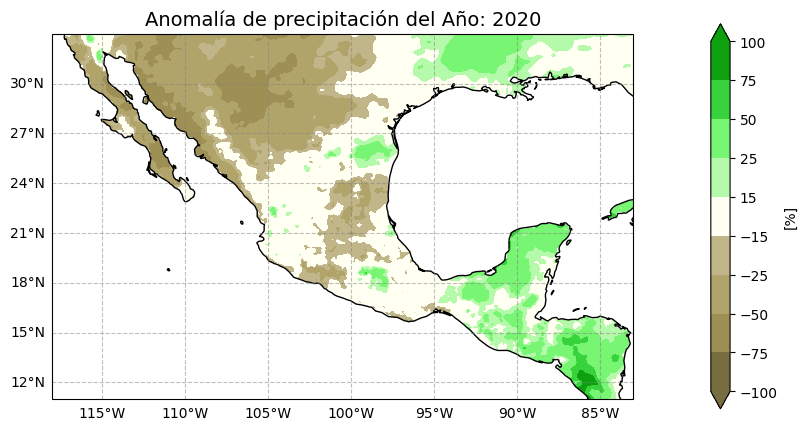

In [55]:
#Vamos a graficar

bounds = [-100.0, -75.0, -50.0, -25, -15.0, 15.0, 25.0, 50.0, 75.0, 100.0]
colors = ['#786D40','#9E8F54','#B0A46A','#C1B689','#FFFFF2','#B5FAAA','#78F573','#38D23C','#0EA00F']

# crear la rampa
my_map = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bounds, my_map.N)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.set_extent([-118,-83, 11, 33], crs=ccrs.PlateCarree())
ax.coastlines()
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False

cs = ax.contourf(lon, lat, anom_perc_rain, levels = bounds, cmap = my_map, norm = norm, extend="both", transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '[%]',shrink=0.5) #shrink nos ayuda a cambiar el tamaño del colorbar
plt.title('Anomalía de precipitación del Año: 2020', fontsize = 14)
plt.show()

#¿Cómo lo interpretamos?

#### <font color="orange"> **Ejemplo 3: Anomalía estandarizada**

In [56]:
#Calculamos anomalía estandarizada

#Primero obtenemos el valor de la desviación estándar del periodo base
std_rain=promedio_ref.std()

anom_std_rain=anom_abs_rain/std_rain

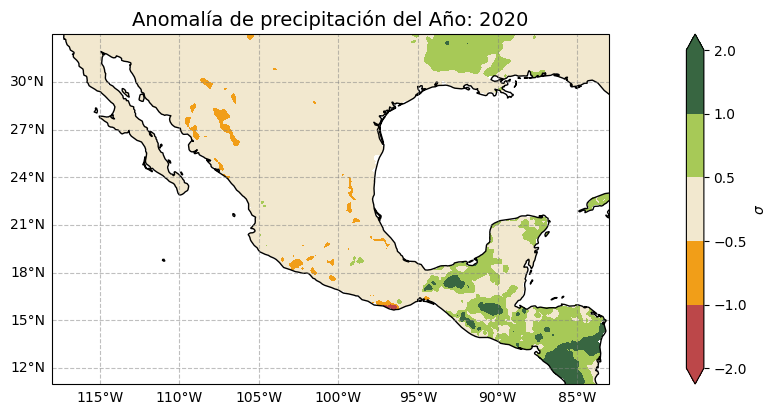

In [57]:
#Graficamos

colors = ['#bc4749','#f19e18','#f2e8cf','#a7c957','#6a994e','#386641']
bounds = [-2.0, -1.0, -0.5, 0.5, 1, 2]

# rampa
my_map = mpl.colors.ListedColormap(colors)
norm = mpl.colors.BoundaryNorm(bounds, my_map.N)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
# Extención del mapa
ax.set_extent([-118,-83, 11, 33], crs=ccrs.PlateCarree())
ax.coastlines()
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False

cs = ax.contourf(lon, lat, anom_std_rain, levels = bounds, cmap = my_map, norm = norm,  extend="both",transform=ccrs.PlateCarree())
plt.colorbar(cs, pad = 0.1, label = '$\sigma$')
plt.title('Anomalía de precipitación del Año: 2020', fontsize = 14)
plt.show() #¿Qué podemos interpretar?

#### <font color="orange"> **Ejemplo 4:**

Ahora, supongamos que ahora vamos a usar el periodo de 1991 - 2010 y de ahí, encontrar qué años han sido los más y los menos lluviosos en México comparado con el periodo base de 1991 - 2000. Vamos paso por paso. Pero antes, ¿Qué tipo de anomalía consideran que queda mejor con lo que se pide?

In [58]:
# Vamos a seleccionar el periodo base
tp_base = rain_Mexico_mm.where((rain_Mexico_mm.time.dt.year > 1990) & (rain_Mexico_mm.time.dt.year < 2001),drop=True)

# Hasta aquí todo es igual, ahora empiezan a cambiar unas cosas.

# Como queremos hacer una serie de tiempo de cada año entonces primero promediamos en el área
baseline_area = tp_base.mean(['longitude','latitude']) # Esto me da una serie de valores

# Ahora obtenemos el promedio de todos los años
baseline_y_mean = baseline_area.mean('time') # Esto da un valor único

# ------------------------------------------------------------------------
# Ahora hay que obtener el promedio anual de cada año desde 1991 - 2010

# Seleccionar los años
yearly_data = rain_Mexico_mm.where((rain_Mexico_mm.time.dt.year > 1990) & (rain_Mexico_mm.time.dt.year < 2011),drop=True)

# Ahora obtenemos el promedio en área
yearly_a_mean = yearly_data.mean(['longitude','latitude'])

# Y el promedio por año
year_means = yearly_a_mean.resample(time = '1YE').mean() # Esto nos da un valor por año

# ----------------------------------------------------------------------------------
# Ahora sí ya podemos obtener la anomalía absoluta

anom_10_20 = year_means - baseline_y_mean


In [59]:
anom_10_20

<xarray.DataArray 'tp' (time: 20)> Size: 160B
array([ 8.12662492,  6.27256983,  2.99132509, -7.28416081,  1.87007731,
       -2.49338317,  3.50872952,  1.53319626, -5.78718624, -8.7377927 ,
       -5.87625034, -3.12599044, -4.55825245,  1.33807037, -3.80371393,
       -2.8784991 ,  0.20450192,  3.8108579 , -5.37640983,  6.49038112])
Coordinates:
  * time     (time) datetime64[ns] 160B 1991-12-31 1992-12-31 ... 2010-12-31
Attributes:
    units:      m
    long_name:  Total precipitation

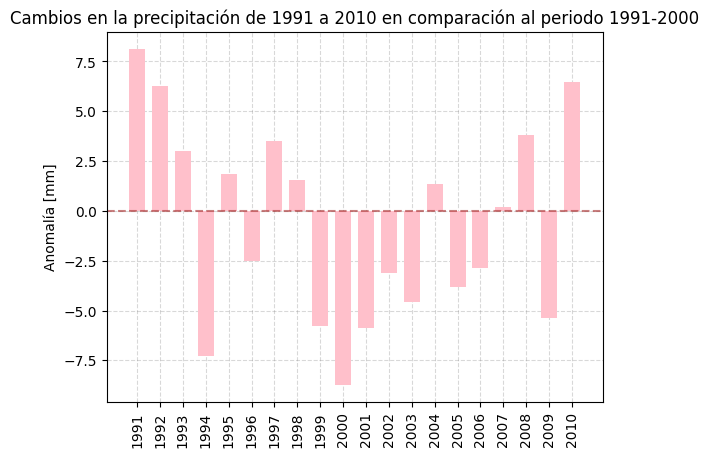

In [60]:
#Vamos a graficar
x = range(1991, 2010 + 1, 1)

fig, ax = plt.subplots()
plt.bar(x, anom_10_20.values, color = 'pink', width = 0.7,zorder=2)
plt.axhline(y = 0, color = 'brown', linestyle='--', alpha = 0.6,zorder=2)
plt.xticks(x, rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.ylabel("Anomalía [mm]")
plt.title("Cambios en la precipitación de 1991 a 2010 en comparación al periodo 1991-2000")
plt.show()

##¿Qué nos dice este gráfico?

**¿Y si obtenemos la anomalía estandarizada?**

In [61]:
# Vamos a usar el promedio de area de antes: baseline_area 
# A esa variable vamos a calcularle su desviación estándar

std_baseline = baseline_area.std('time') #Esto se saca al periodo de la climatología (base)

# Y ya con eso podemos obtener la anomalía estandarizada

std_anom = (year_means - baseline_y_mean) / std_baseline

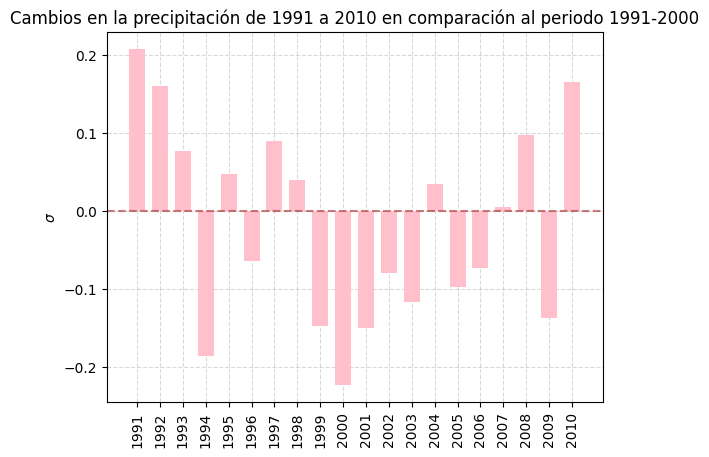

In [62]:
#Vamos a graficar

x = np.arange(1991, 2010 + 1, 1)
fig, ax = plt.subplots()
plt.bar(x, std_anom.values, color = 'pink', width = 0.7,zorder=2)
plt.axhline(y = 0, color = 'brown', linestyle='--', alpha = 0.6)
plt.xticks(x, rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.ylabel("$\sigma$")
plt.title("Cambios en la precipitación de 1991 a 2010 en comparación al periodo 1991-2000")
plt.show() 
#¿Qué les dice esta gráfica?

### <font color="purple"> **Ejercicio 2**

A partir de los datos `Temp_1990_2020.nc` de Australia:

* Considerando como periodo base los meses de diciembre de 1990-2010, encuentra en qué años los meses de diciembre han sido anormalmente más o menos cálidos en Australia durante 1990-2022. ¿Qué año fue extremadamente cálido?
  
* A partir del año extremadamente cálido, muestra qué tan cálido fue Australia en el 2019 considerando el periodo base de 1990-2010.

In [63]:
#Vamos a cargar los datos
ruta = '/home/jovyan/Clase/TemasSelectos/data/Temp_1990_2020.nc'
ds = xr.open_dataset(ruta)

#Seleccionamos la variable de interés
t=ds["t2m"]

In [64]:
#Seleccionando el periodo base
clima_base=t[(t.time.dt.month==12)&(t.time.dt.year>1989)&(t.time.dt.year<2011)]-273.15 #Convirtiendo los datos de Kelvin a Celcius

#Promedio de área
pro=clima_base.mean(["latitude","longitude"])

#Promedio en el tiempo y desvest
proT=pro.mean("time")
dest_T=pro.std("time")

#Periodo de estudio
periodo_estudio=t[(t.time.dt.month==12)&(t.time.dt.year>1989)&(t.time.dt.year<2023)]-273.15

# Ahora obtenemos el promedio en área
periodo_area_mean = periodo_estudio.mean(['longitude','latitude'])

In [65]:
#Calculamos la anomalía estandarizada
anomest=(periodo_area_mean-proT)/dest_T

#Vamos a localizar el año con el diciembre más anómalamente cálido
#Encontrando la anomalía estandarizada más alta 
anom_max=anomest.max()

#Localizando el año donde se presentó dicho valor
anio_max=(anomest.where(anomest==anom_max,drop=True)).time.dt.year
print(f"Añio con el diciembre más cálido fue: {anio_max.values}")

Añio con el diciembre más cálido fue: [2019]


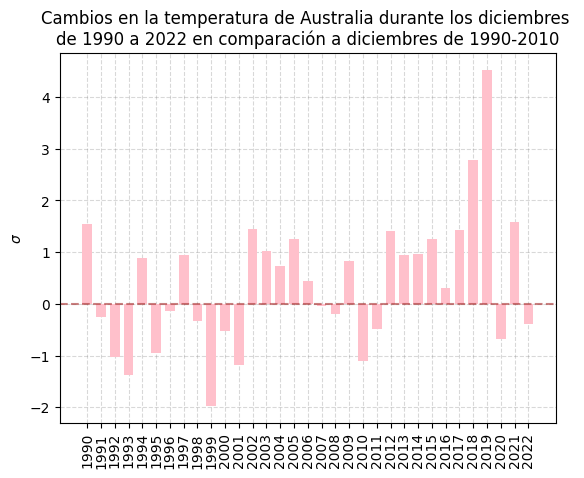

In [66]:
# Hagamos unp plot para observar los resultados
x = np.arange(1990, 2023, 1)
fig, ax = plt.subplots()
plt.bar(x, anomest.values, color = 'pink', width = 0.7,zorder=2)
plt.axhline(y = 0, color = 'brown', linestyle='--', alpha = 0.6)
plt.xticks(x, rotation = 90)
plt.grid(linestyle="--",color="gray",alpha=0.3,zorder=1)
plt.ylabel("$\sigma$")
plt.title("Cambios en la temperatura de Australia durante los diciembres \nde 1990 a 2022 en comparación a diciembres de 1990-2010")
plt.show() 


In [67]:
#Punto 2: ¿Qué tan cálido fue Australia durante ese año?

#Periodo base
base_time=t[(t.time.dt.year>1989)&(t.time.dt.year<2011)]-273.15

#Dado que queremos visualizar la distribución espacial, solo promediamos en el tiempo
mean_time_T=base_time.mean(["time"])

#Año de estudio
anio_T=t[(t.time.dt.year==2019)]-273.15

In [73]:
#Como queremos ver qué tan cálido fue ese año, vamos a calcular la anomalñia absoluta
anom_abs_T=anio_T-mean_time_T

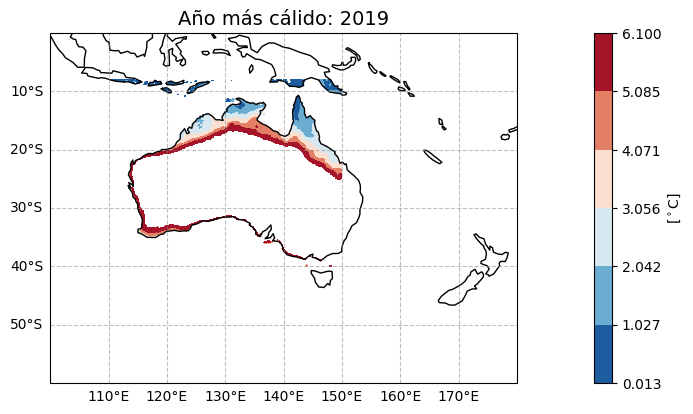

In [76]:
# Vamos a graficar
bounds = np.linspace(0.013,6.1,7)
colors = ['#372001','#8C510B','#BF812E','#DFC27E','#F6E8C3','#F5F5F5','#C7EAE4','#80CEC1','#369790','#01665E','#003C30','#92C6DE','#2165AC','#063062']

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(2, 1, 1, projection=ccrs.PlateCarree())
ax.coastlines()
ax.set_extent([100,180,-60, 0], crs=ccrs.PlateCarree())
gl=ax.gridlines(draw_labels = True, dms = True, x_inline = False, y_inline = False, color = 'gray', alpha = 0.5, linestyle='--')
gl.top_labels = gl.right_labels = False

cs = ax.contourf(anom_abs_T.longitude, anom_abs_T.latitude, anom_abs_T[0], levels = bounds,  cmap='RdBu_r',  transform=ccrs.PlateCarree())
cmap='RdBu_r'
plt.colorbar(cs, pad = 0.1, label = '[$^\circ$C]')
plt.title('Año más cálido: 2019', fontsize = 14)
plt.show()

-------------------

### `**IMPORTANTE**`

**No todas las anomalías se consideran medidas de extremos**, ya que en general estas describen únicamente la desviación de un valor respecto a un promedio o referencia. Las anomalías absolutas y porcentuales indican cuánto cambia una variable, ya sea en términos reales o relativos, pero no permiten determinar si ese cambio es inusual dentro de la variabilidad de los datos. En cambio, la anomalía estandarizada sí puede considerarse una medida de extremos, ya que incorpora la desviación estándar y permite identificar valores que son estadísticamente raros o poco frecuentes. 

Por el contrario, las medidas de extremos (como percentiles, máximos o índices de extremos) están diseñadas específicamente para identificar valores raros o poco frecuentes dentro de una distribución.